In [107]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn.linear_model import LinearRegression

In [108]:
df = pd.read_csv('weight-height.csv')
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
8550,60.483946,110.565497
8551,63.423372,129.921671
8552,65.584057,155.942671
8553,67.429971,151.678405


In [109]:
df.shape

(8555, 2)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8555 entries, 0 to 8554
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Height  8555 non-null   float64
 1   Weight  8555 non-null   float64
dtypes: float64(2)
memory usage: 133.8 KB


In [111]:
df.isna().sum()

Height    0
Weight    0
dtype: int64

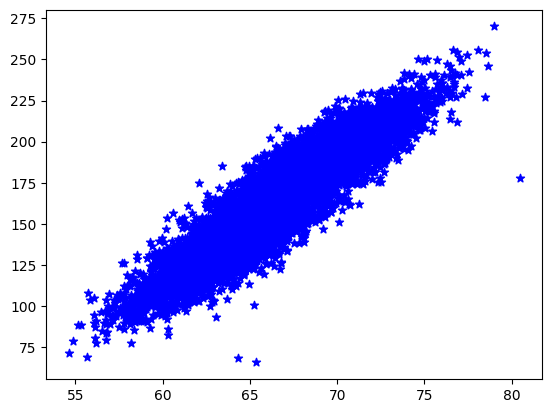

In [112]:
plt.scatter(df['Height'], df['Weight'], marker = '*', color = 'b')
plt.show()

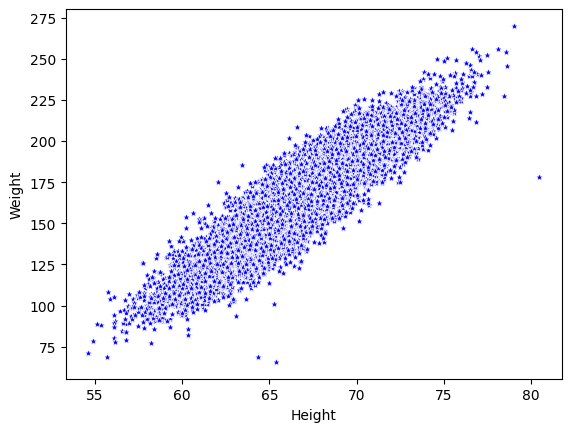

In [113]:
sns.scatterplot(x = df['Height'],y = df['Weight'], marker = '*', color = 'b')
plt.show()

In [114]:
x = df[['Height']]
y = df[['Weight']]

In [115]:
x.head()

,Height
0,73.847017
1,68.781904
2,74.110105
3,71.730978
4,69.881796


In [116]:
y.head()

,Weight
0,241.893563
1,162.310473
2,212.740856
3,220.042470
4,206.349801


In [117]:
xtrain, xtest, ytrain, ytest = tts(x,y,test_size=0.2, random_state = 1)

In [118]:
print(f'Shape of XTRAIN data: {xtrain.shape}')
print(f'Shape of YTRAIN data: {ytrain.shape}')
print(f'Shape of XTEST data: {xtest.shape}')
print(f'Shape of YTEST data: {ytest.shape}')

Shape of XTRAIN data: (6844, 1)
Shape of YTRAIN data: (6844, 1)
Shape of XTEST data: (1711, 1)
Shape of YTEST data: (1711, 1)


In [119]:
print(xtrain.head())
print(ytrain.head())

         Height
2677  70.815880
6714  58.037418
3500  72.738970
2227  67.497015
7428  65.073874
          Weight
2677  186.597896
6714  100.496831
3500  187.222909
2227  178.786914
7428  141.810065


In [120]:
lr = LinearRegression()

In [121]:
lr.fit(xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [122]:
lr.score(xtrain, ytrain)

0.8515669389945234

In [123]:
lr.score(xtest,ytest)

0.8530239552951296

In [124]:
df

,Height,Weight
0,73.847017,241.893563
1,68.781904,162.310473
2,74.110105,212.740856
3,71.730978,220.042470
4,69.881796,206.349801
...,...,...
8550,60.483946,110.565497
8551,63.423372,129.921671
8552,65.584057,155.942671
8553,67.429971,151.678405


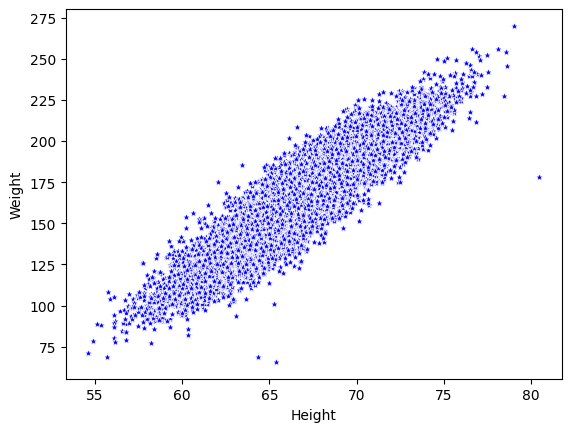

In [125]:
sns.scatterplot(x=x['Height'], y=y['Weight'], marker = '*',color = 'b')
plt.show()

In [126]:
y_pred = lr.predict(xtest) # Generates predicted weights only for unseen test data. Used for evaluation (MAE, MSE, plots)
y_pred

array([[152.17304515],
       [196.41586173],
       [179.80696035],
       ...,
       [186.99437908],
       [155.48790443],
       [ 90.72394577]])

In [156]:
y_pred2 = lr.predict(x) # Generates predictions for all 8555 samples. Used for visualization and error analysis
y_pred2

array([[219.64454445],
       [180.71624158],
       [221.66652971],
       ...,
       [156.13894813],
       [170.32586239],
       [120.30675649]])

In [127]:
y_pred1 = lr.predict([[73]])
y_pred1

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[213.13473208]])

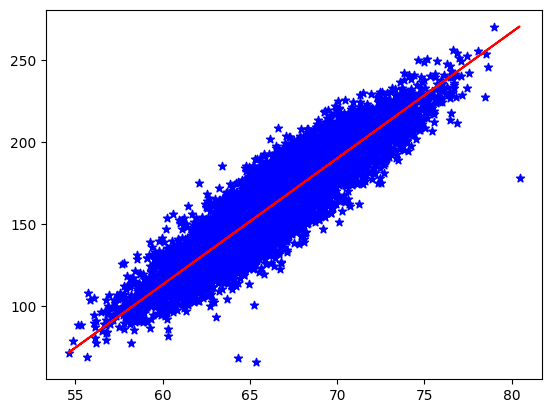

In [128]:
# Visualization: Entire Dataset
plt.scatter(x,y,marker = '*',color = 'b')
plt.plot(x,lr.predict(x),color = 'r')
plt.show()

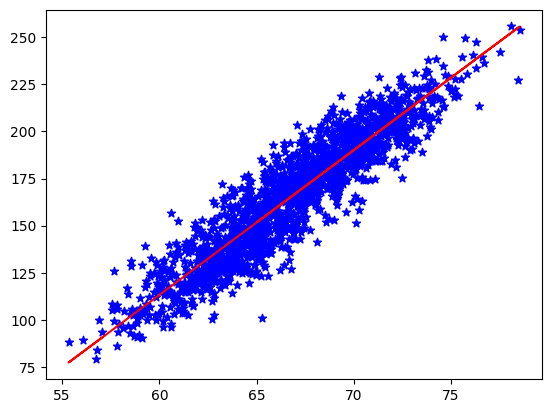

In [129]:
# Visualization: Test Data Only

plt.scatter(xtest,ytest,marker = '*',color = 'b')
plt.plot(xtest,lr.predict(xtest),color = 'r')
plt.show()

In [130]:
df ['Predicted Weight'] = lr.predict(x)

In [131]:
df

,Height,Weight,Predicted Weight
0,73.847017,241.893563,219.644544
1,68.781904,162.310473,180.716242
2,74.110105,212.740856,221.666530
3,71.730978,220.042470,203.381572
4,69.881796,206.349801,189.169542
...,...,...,...
8550,60.483946,110.565497,116.941664
8551,63.423372,129.921671,139.532841
8552,65.584057,155.942671,156.138948
8553,67.429971,151.678405,170.325862


In [132]:
df['Error'] = df['Weight'] - df['Predicted Weight']

In [133]:
df

,Height,Weight,Predicted Weight,Error
0,73.847017,241.893563,219.644544,22.249019
1,68.781904,162.310473,180.716242,-18.405769
2,74.110105,212.740856,221.666530,-8.925674
3,71.730978,220.042470,203.381572,16.660898
4,69.881796,206.349801,189.169542,17.180259
...,...,...,...,...
8550,60.483946,110.565497,116.941664,-6.376167
8551,63.423372,129.921671,139.532841,-9.611170
8552,65.584057,155.942671,156.138948,-0.196277
8553,67.429971,151.678405,170.325862,-18.647457


In [134]:
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import mean_squared_error as mse

In [135]:
test_mae = mae(ytest,lr.predict(xtest))
test_mae

9.892606004794652

In [136]:
test_mse = mse(ytest,lr.predict(xtest))
test_mse

154.43351470768653

In [140]:
df

,Height,Weight,Predicted Weight,Error
0,73.847017,241.893563,219.644544,22.249019
1,68.781904,162.310473,180.716242,-18.405769
2,74.110105,212.740856,221.666530,-8.925674
3,71.730978,220.042470,203.381572,16.660898
4,69.881796,206.349801,189.169542,17.180259
...,...,...,...,...
8550,60.483946,110.565497,116.941664,-6.376167
8551,63.423372,129.921671,139.532841,-9.611170
8552,65.584057,155.942671,156.138948,-0.196277
8553,67.429971,151.678405,170.325862,-18.647457


In [146]:
ypred = lr.predict([[107]])
ypred

C:\Program Files\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[474.44426364]])

In [151]:
c = lr.intercept_
c

array([-347.91220334])

In [152]:
m = lr.coef_
m

array([[7.68557446]])

In [153]:
y = m*107 + c
y

array([[474.44426364]])